# QRT Match Result Prediction – Data Exploration

Load training data, merge home/away team stats with labels, and run a simple baseline.

## Load Data

Load the 3 core training files: home team stats, away team stats, and target labels (HOME_WINS / DRAW / AWAY_WINS).

In [30]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "Train_Data"

# Load team stats (one row per match)
home_team = pd.read_csv(TRAIN_DIR / "train_home_team_statistics_df.csv")
away_team = pd.read_csv(TRAIN_DIR / "train_away_team_statistics_df.csv")
y_train = pd.read_csv(DATA_DIR / "Y_train_1rknArQ.csv")

print("Shapes:", home_team.shape, away_team.shape, y_train.shape)

Shapes: (12303, 143) (12303, 143) (12303, 4)


## Merge Home & Away Team Stats

Prefix columns with `home_` / `away_` to distinguish sides, then merge both team tables with the target labels on `ID`. Result: one row per match with all home + away stats + outcome.

In [31]:
# Prefix columns so we can merge home and away (skip if already prefixed)
home_team = home_team.rename(columns={c: f"home_{c}" for c in home_team.columns if c != "ID" and not c.startswith("home_")})
away_team = away_team.rename(columns={c: f"away_{c}" for c in away_team.columns if c != "ID" and not c.startswith("away_")})

# Merge on ID
X_team = home_team.merge(away_team, on="ID", how="inner").merge(y_train, on="ID", how="inner")
print("Merged shape:", X_team.shape)
X_team.head()

Merged shape: (12303, 288)


,ID,home_LEAGUE,home_TEAM_NAME,home_TEAM_SHOTS_TOTAL_season_sum,home_TEAM_SHOTS_INSIDEBOX_season_sum,home_TEAM_SHOTS_OFF_TARGET_season_sum,home_TEAM_SHOTS_ON_TARGET_season_sum,home_TEAM_SHOTS_OUTSIDEBOX_season_sum,home_TEAM_PASSES_season_sum,home_TEAM_SUCCESSFUL_PASSES_season_sum,...,away_TEAM_ATTACKS_5_last_match_std,away_TEAM_PENALTIES_5_last_match_std,away_TEAM_SUBSTITUTIONS_5_last_match_std,away_TEAM_BALL_SAFE_5_last_match_std,away_TEAM_DANGEROUS_ATTACKS_5_last_match_std,away_TEAM_INJURIES_5_last_match_std,away_TEAM_GOALS_5_last_match_std,HOME_WINS,DRAW,AWAY_WINS
0,0,Ligue 1,Toulouse,3.0,2.0,5.0,2.0,1.0,2.0,2.0,...,0.0,6.0,8.0,4.0,3.0,2.0,3.0,0,0,1
1,1,Ligue 2,Brest,6.0,8.0,3.0,6.0,5.0,8.0,7.0,...,1.0,8.0,4.0,10.0,0.0,5.0,3.0,0,1,0
2,2,Serie A,Sampdoria,4.0,2.0,5.0,2.0,8.0,1.0,1.0,...,4.0,0.0,8.0,3.0,0.0,9.0,6.0,0,0,1
3,3,League One,Coventry City,7.0,5.0,5.0,6.0,6.0,9.0,9.0,...,2.0,0.0,5.0,6.0,3.0,NaN,2.0,1,0,0
4,4,Premier League,Wolverhampton Wanderers,3.0,3.0,2.0,3.0,4.0,4.0,3.0,...,4.0,9.0,4.0,1.0,4.0,6.0,5.0,0,1,0


## Exploratory Data Analysis (EDA)

Inspect the merged dataset: check value ranges, missing values, data types, and distributions. Key findings:
- All team stats are **discretized to integers 0–10** (not truly standardized)
- **Missing values are uneven** across columns (up to ~27% for some stats)
- Some columns show **bimodal distributions** (many zeros + spread values)

In [32]:
X_team.describe(include="all")

,ID,home_LEAGUE,home_TEAM_NAME,home_TEAM_SHOTS_TOTAL_season_sum,home_TEAM_SHOTS_INSIDEBOX_season_sum,home_TEAM_SHOTS_OFF_TARGET_season_sum,home_TEAM_SHOTS_ON_TARGET_season_sum,home_TEAM_SHOTS_OUTSIDEBOX_season_sum,home_TEAM_PASSES_season_sum,home_TEAM_SUCCESSFUL_PASSES_season_sum,...,away_TEAM_ATTACKS_5_last_match_std,away_TEAM_PENALTIES_5_last_match_std,away_TEAM_SUBSTITUTIONS_5_last_match_std,away_TEAM_BALL_SAFE_5_last_match_std,away_TEAM_DANGEROUS_ATTACKS_5_last_match_std,away_TEAM_INJURIES_5_last_match_std,away_TEAM_GOALS_5_last_match_std,HOME_WINS,DRAW,AWAY_WINS
count,12303.000000,12303,12303,12043.000000,10918.000000,12303.000000,12301.000000,10916.000000,10890.000000,10919.000000,...,12303.000000,12290.000000,12212.000000,10467.000000,12303.000000,8990.000000,12301.000000,12303.000000,12303.000000,12303.000000
unique,NaN,13,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Serie A,Exeter City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1966,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,6151.000000,NaN,NaN,4.391182,4.299872,4.511339,4.150882,4.524643,4.350597,4.130049,...,3.936032,3.701302,3.271536,3.804911,3.758026,3.886207,3.687342,0.435341,0.258961,0.305698
std,3551.714516,NaN,NaN,2.871062,2.928012,2.806821,2.861291,2.845130,2.908079,2.900489,...,2.823259,3.696370,3.335124,2.863371,2.814694,2.795961,2.856081,0.495822,0.438082,0.460721
min,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3075.500000,NaN,NaN,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000
50%,6151.000000,NaN,NaN,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000
75%,9226.500000,NaN,NaN,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,7.000000,6.000000,6.000000,6.000000,6.000000,6.000000,1.000000,1.000000,1.000000


1. Data is discretized to integers 0–10, not truly "standardized"

The README says values are "standardized," but look at the statistics:
- min = 0, max = 10 for every numeric column
- 25th percentile = 2, median = 4, 75th percentile = 6 (almost uniformly across columns)
- All values are whole numbers

This is not z-score (would have negative values, mean ≈ 0, std ≈ 1) and not min-max scaling (would produce continuous/fractional values). The data has been discretized — most likely quantile-binned into 11 ordinal buckets. It's all integers, no exceptions.

So the two datasets use different discretization scales: team stats → 0–10, player stats → 0–100. This is worth knowing because:
Tree-based models (like your GradientBoosting) handle this fine — they just split on thresholds regardless of scale
Linear models or neural nets would need to account for the different scales between team (0–10) and player-derived (0–100) features
The coarse 11-level granularity on team stats means there are many ties, which limits how much signal any single feature can carry

2. Significant and uneven missing values (NaN)

Total rows = 12,303, but the count row varies wildly across columns:
Column (example)	Count	Missing	% Missing
home_TEAM_SHOTS_OFF_TARGET_season_sum	12,303	0	0%
home_TEAM_SHOTS_TOTAL_season_sum	12,043	260	2.1%
home_TEAM_SHOTS_INSIDEBOX_season_sum	10,918	1,385	11.3%
home_TEAM_PASSES_season_sum	10,890	1,413	11.5%
away_TEAM_BALL_SAFE_5_last_match_std	10,467	1,836	14.9%
away_TEAM_INJURIES_5_last_match_std	8,990	3,313	26.9%

Some columns have up to ~27% missing data. The current notebook fills NaN with the median, but this pattern suggests certain stats simply aren't tracked in some leagues or seasons. A missing-value indicator feature (is_missing flag) could carry useful signal.

3. Bimodal distributions on some columns
Columns like away_TEAM_PENALTIES_5_last_match_std and away_TEAM_SUBSTITUTIONS_5_last_match_std show 25th percentile = 0 but median = 3–5, suggesting a chunk of values are exactly 0 (probably matches early in the season or leagues that don't track that stat) and the rest spread out — a bimodal pattern.

In [33]:
X_team.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12303 entries, 0 to 12302
Columns: 288 entries, ID to AWAY_WINS
dtypes: float64(280), int64(4), object(4)
memory usage: 27.0+ MB


## Player Stats Analysis — Feature Selection

Before deciding which player stats to use, we check all 51 base stats on 4 criteria:
1. **Correlation with target** — does this stat relate to match outcome?
2. **Missing rate** — is it available for enough matches?
3. **Domain knowledge** — does this stat logically contribute to match outcome? (with reasoning for each)
4. **Inter-feature correlation** — drop redundant stats that are >0.95 correlated with a better candidate

Only stats that pass all 4 checks will be included in `CONTRIBUTION_COLS`.

In [34]:
import re

home_players_raw = pd.read_csv(TRAIN_DIR / "train_home_player_statistics_df.csv")

# Get all _season_average columns (one per base stat)
player_avg_cols = [c for c in home_players_raw.columns if c.endswith("_season_average")]
print(f"Total player _season_average columns: {len(player_avg_cols)}")

# Aggregate player stats per match (mean across all players in team)
player_agg = home_players_raw.groupby("ID")[player_avg_cols].mean()
player_agg = player_agg.merge(y_train, on="ID", how="inner")

y_tmp = np.argmax(player_agg[["HOME_WINS", "DRAW", "AWAY_WINS"]].values, axis=1)

# --- 1) Correlation with target ---
corr_with_target = player_agg[player_avg_cols].corrwith(pd.Series(y_tmp, index=player_agg.index)).abs()

# --- 2) Missing rate ---
missing_rate = player_agg[player_avg_cols].isna().mean()

# --- 4) Domain knowledge ---
# Categorize each stat based on football reasoning:
#   "keep"   = directly impacts match outcome (offensive output, defensive solidity, passing quality, GK ability)
#   "skip"   = too rare, metadata, or indirect signal
DOMAIN = {
    # Offensive — directly creates goals/chances
    "PLAYER_GOALS":                    ("keep",  "primary offensive output"),
    "PLAYER_ASSISTS":                  ("keep",  "direct goal contribution"),
    "PLAYER_SHOTS_TOTAL":              ("keep",  "attacking intent"),
    "PLAYER_SHOTS_ON_TARGET":          ("keep",  "shot quality"),
    "PLAYER_SHOTS_OFF_TARGET":         ("keep",  "shot volume context"),
    "PLAYER_KEY_PASSES":               ("keep",  "chance creation"),
    "PLAYER_BIG_CHANCES_CREATED":      ("keep",  "high-quality chance creation"),
    "PLAYER_SUCCESSFUL_DRIBBLES":      ("keep",  "ability to beat defenders"),
    "PLAYER_ACCURATE_CROSSES":         ("keep",  "crossing delivery quality"),
    "PLAYER_OFFSIDES":                 ("skip",  "indirect — tactical positioning, not contribution"),

    # Defensive — prevents opponent from scoring
    "PLAYER_TACKLES":                  ("keep",  "defensive engagement"),
    "PLAYER_INTERCEPTIONS":            ("keep",  "reading the game"),
    "PLAYER_CLEARANCES":               ("keep",  "danger removal"),
    "PLAYER_BLOCKED_SHOTS":            ("keep",  "shot blocking"),
    "PLAYER_AERIALS_WON":              ("keep",  "aerial dominance"),
    "PLAYER_DUELS_WON":                ("keep",  "1v1 success"),
    "PLAYER_TOTAL_DUELS":              ("skip",  "redundant — duels_won is more informative"),
    "PLAYER_DUELS_LOST":               ("skip",  "redundant — inverse of duels_won ratio"),
    "PLAYER_DRIBBLED_PAST":            ("skip",  "defensive weakness — inverse signal, noisy"),
    "PLAYER_DISPOSSESSED":             ("skip",  "losing the ball — indirect"),
    "PLAYER_CLEARANCE_OFFLINE":        ("skip",  "too rare and specific"),

    # Passing — ball circulation quality
    "PLAYER_PASSES":                   ("keep",  "passing volume"),
    "PLAYER_ACCURATE_PASSES":          ("keep",  "passing reliability"),
    "PLAYER_ACCURATE_PASSES_PERCENTAGE": ("keep", "passing accuracy rate"),
    "PLAYER_LONG_BALLS":               ("skip",  "style-dependent, not quality indicator"),
    "PLAYER_LONG_BALLS_WON":           ("skip",  "too specific, low signal"),
    "PLAYER_TOTAL_CROSSES":            ("skip",  "redundant — accurate_crosses is better"),

    # Goalkeeping — shot stopping ability
    "PLAYER_SAVES":                    ("keep",  "primary GK contribution"),
    "PLAYER_SAVES_INSIDE_BOX":         ("keep",  "GK close-range ability"),
    "PLAYER_PUNCHES":                  ("skip",  "GK style choice, not quality"),
    "PLAYER_GOALKEEPER_GOALS_CONCEDED": ("keep", "GK effectiveness (inverse)"),
    "PLAYER_GOALS_CONCEDED":           ("skip",  "redundant with GK goals conceded"),

    # Discipline — impacts team with 10 men
    "PLAYER_FOULS":                    ("keep",  "risk of cards / free kicks"),
    "PLAYER_FOULS_DRAWN":              ("keep",  "ability to win free kicks"),
    "PLAYER_YELLOWCARDS":              ("keep",  "suspension risk"),
    "PLAYER_REDCARDS":                 ("skip",  "too rare to be reliable"),

    # Rating
    "PLAYER_RATING":                   ("keep",  "overall match performance score"),

    # Rare events — too infrequent for stable signal
    "PLAYER_BIG_CHANCES_MISSED":       ("skip",  "rare + noisy"),
    "PLAYER_HIT_WOODWORK":             ("skip",  "very rare, random"),
    "PLAYER_OWN_GOALS":                ("skip",  "extremely rare"),
    "PLAYER_ERROR_LEAD_TO_GOAL":       ("skip",  "extremely rare"),
    "PLAYER_PENALTIES_SCORED":         ("skip",  "very rare event"),
    "PLAYER_PENALTIES_MISSES":         ("skip",  "very rare event"),
    "PLAYER_PENALTIES_WON":            ("skip",  "very rare event"),
    "PLAYER_PENALTIES_COMMITTED":      ("skip",  "very rare event"),
    "PLAYER_PENALTIES_SAVED":          ("skip",  "very rare event"),
    "PLAYER_SHOTS_BLOCKED":            ("skip",  "ambiguous — could be attacker's shot blocked"),

    # Metadata — not a performance contribution
    "PLAYER_CAPTAIN":                  ("skip",  "binary flag, not performance metric"),
    "PLAYER_STARTING_LINEUP":          ("skip",  "selection info, not contribution"),
    "PLAYER_MINUTES_PLAYED":           ("skip",  "playing time, not quality"),
    "PLAYER_DRIBBLED_ATTEMPTS":        ("skip",  "redundant — successful_dribbles is better"),
}

# Build analysis table
base_stats = [re.sub(r"_season_average$", "", c) for c in player_avg_cols]
analysis = pd.DataFrame({
    "base_stat": base_stats,
    "column": player_avg_cols,
    "target_corr": corr_with_target.values,
    "missing_rate": missing_rate.values,
    "domain": [DOMAIN.get(bs, ("skip", "unknown"))[0] for bs in base_stats],
    "reason": [DOMAIN.get(bs, ("skip", "unknown"))[1] for bs in base_stats],
}).sort_values(["domain", "target_corr"], ascending=[True, False])

print("--- All 51 Player Stats ---")
print(analysis[["base_stat", "target_corr", "missing_rate", "domain", "reason"]]
      .to_string(index=False, float_format="{:.4f}".format))

Total player _season_average columns: 51
--- All 51 Player Stats ---
                        base_stat  target_corr  missing_rate domain                                            reason
                     PLAYER_GOALS       0.1425        0.0000   keep                          primary offensive output
                PLAYER_KEY_PASSES       0.1377        0.1120   keep                                   chance creation
       PLAYER_BIG_CHANCES_CREATED       0.1355        0.1179   keep                      high-quality chance creation
           PLAYER_SHOTS_ON_TARGET       0.1351        0.1120   keep                                      shot quality
                   PLAYER_ASSISTS       0.1257        0.0000   keep                          direct goal contribution
           PLAYER_ACCURATE_PASSES       0.1248        0.1120   keep                               passing reliability
PLAYER_ACCURATE_PASSES_PERCENTAGE       0.1199        0.2279   keep                             passing a

In [35]:
# Apply all 4 filters:
#   1) Correlation with target >= threshold
#   2) Missing rate <= threshold
#   3) Domain knowledge == "keep"
#   4) Drop redundant stats (|inter-correlation| > 0.95, keep the one with higher target corr)
CORR_THRESHOLD = 0.02
MISSING_THRESHOLD = 0.50
INTER_CORR_THRESHOLD = 0.95

# --- Steps 1-3: filter by target corr, missing rate, domain ---
candidates = analysis[
    (analysis["domain"] == "keep") &
    (analysis["target_corr"] >= CORR_THRESHOLD) &
    (analysis["missing_rate"] <= MISSING_THRESHOLD)
].copy()

failed_early = analysis[~analysis["column"].isin(candidates["column"])]

print(f"After checks 1-3: {len(candidates)} candidates from {len(analysis)} total\n")

# --- Step 4: drop redundant pairs among candidates ---
candidate_cols = candidates["column"].tolist()
inter_corr = player_agg[candidate_cols].corr().abs()

redundant_drop = set()
redundant_pairs = []
for i in range(len(candidate_cols)):
    for j in range(i + 1, len(candidate_cols)):
        r = inter_corr.iloc[i, j]
        if r > INTER_CORR_THRESHOLD:
            a, b = candidate_cols[i], candidate_cols[j]
            corr_a = corr_with_target.get(a, 0)
            corr_b = corr_with_target.get(b, 0)
            drop = b if corr_a >= corr_b else a
            keep = a if drop == b else b
            if drop not in redundant_drop:
                redundant_drop.add(drop)
                base_drop = re.sub(r"_season_average$", "", drop)
                base_keep = re.sub(r"_season_average$", "", keep)
                redundant_pairs.append((base_drop, base_keep, round(r, 3)))

passed = candidates[~candidates["column"].isin(redundant_drop)]

print(f"PASSED: {len(passed)} stats")
print(passed[["base_stat", "target_corr", "missing_rate", "reason"]].to_string(index=False, float_format="{:.4f}".format))

if redundant_pairs:
    print(f"\nDropped {len(redundant_pairs)} redundant stats (|inter-corr| > {INTER_CORR_THRESHOLD}):")
    for dropped, kept, r in redundant_pairs:
        print(f"  {dropped:40s} → redundant with {kept} (r={r})")

print(f"\nFiltered out (checks 1-3): {len(failed_early)} stats")
for _, row in failed_early.iterrows():
    reasons = []
    if row["domain"] == "skip": reasons.append(f"domain: {row['reason']}")
    if row["target_corr"] < CORR_THRESHOLD: reasons.append(f"low corr ({row['target_corr']:.4f})")
    if row["missing_rate"] > MISSING_THRESHOLD: reasons.append(f"high missing ({row['missing_rate']:.1%})")
    print(f"  {row['base_stat']:45s}  |  {'; '.join(reasons)}")

SELECTED_CONTRIBUTION_COLS = passed["column"].tolist()
print(f"\nFinal CONTRIBUTION_COLS: {len(SELECTED_CONTRIBUTION_COLS)} columns")

After checks 1-3: 20 candidates from 51 total

PASSED: 19 stats
                        base_stat  target_corr  missing_rate                          reason
                     PLAYER_GOALS       0.1425        0.0000        primary offensive output
                PLAYER_KEY_PASSES       0.1377        0.1120                 chance creation
       PLAYER_BIG_CHANCES_CREATED       0.1355        0.1179    high-quality chance creation
           PLAYER_SHOTS_ON_TARGET       0.1351        0.1120                    shot quality
                   PLAYER_ASSISTS       0.1257        0.0000        direct goal contribution
           PLAYER_ACCURATE_PASSES       0.1248        0.1120             passing reliability
PLAYER_ACCURATE_PASSES_PERCENTAGE       0.1199        0.2279           passing accuracy rate
               PLAYER_SHOTS_TOTAL       0.1172        0.1120                attacking intent
                PLAYER_CLEARANCES       0.0956        0.1120                  danger removal
 PLAYE

## Player-Level Features

Aggregate each selected player stat at the **team level** (mean across all players per match). This preserves individual stat signals instead of compressing them into a single contribution score.

Also keep `PLAYER_RATING_5_last_match_average` as a separate team-level feature (mean rating across all players).

In [36]:
RATING_COL = "PLAYER_RATING_5_last_match_average"
CONTRIBUTION_COLS = SELECTED_CONTRIBUTION_COLS
print(f"Using {len(CONTRIBUTION_COLS)} contribution cols + rating")

# Columns to aggregate: selected stats + rating
agg_cols = CONTRIBUTION_COLS + [RATING_COL]


def player_team_agg(player_df, side_prefix):
    """
    Aggregate each selected player stat at team level (mean across all players per match).
    Returns one row per ID with columns like {side_prefix}_player_GOALS_avg, etc.
    """
    available = [c for c in agg_cols if c in player_df.columns]
    team_agg = player_df.groupby("ID")[available].mean()
    team_agg.columns = [f"{side_prefix}_player_{c}" for c in available]
    return team_agg.reset_index()


home_players = pd.read_csv(TRAIN_DIR / "train_home_player_statistics_df.csv")
away_players = pd.read_csv(TRAIN_DIR / "train_away_player_statistics_df.csv")

home_player_agg = player_team_agg(home_players, "home")
away_player_agg = player_team_agg(away_players, "away")

player_features = home_player_agg.merge(away_player_agg, on="ID", how="outer")
print(f"Player features shape: {player_features.shape}")
print(f"Columns: {list(player_features.columns)}")
player_features.head()

X_team = X_team.merge(player_features, on="ID", how="left")
player_feat_cols = [c for c in player_features.columns if c != "ID"]
print(f"X_team shape after merge: {X_team.shape}")

Using 19 contribution cols + rating
Player features shape: (12303, 41)
Columns: ['ID', 'home_player_PLAYER_GOALS_season_average', 'home_player_PLAYER_KEY_PASSES_season_average', 'home_player_PLAYER_BIG_CHANCES_CREATED_season_average', 'home_player_PLAYER_SHOTS_ON_TARGET_season_average', 'home_player_PLAYER_ASSISTS_season_average', 'home_player_PLAYER_ACCURATE_PASSES_season_average', 'home_player_PLAYER_ACCURATE_PASSES_PERCENTAGE_season_average', 'home_player_PLAYER_SHOTS_TOTAL_season_average', 'home_player_PLAYER_CLEARANCES_season_average', 'home_player_PLAYER_GOALKEEPER_GOALS_CONCEDED_season_average', 'home_player_PLAYER_ACCURATE_CROSSES_season_average', 'home_player_PLAYER_BLOCKED_SHOTS_season_average', 'home_player_PLAYER_SUCCESSFUL_DRIBBLES_season_average', 'home_player_PLAYER_SAVES_INSIDE_BOX_season_average', 'home_player_PLAYER_SAVES_season_average', 'home_player_PLAYER_RATING_season_average', 'home_player_PLAYER_DUELS_WON_season_average', 'home_player_PLAYER_YELLOWCARDS_season_a

## Target Distribution

Check the balance of outcomes (HOME_WINS vs DRAW vs AWAY_WINS) to understand class imbalance — important for choosing metrics and model evaluation.

In [37]:
# Target distribution
print(y_train[["HOME_WINS", "DRAW", "AWAY_WINS"]].sum())
y_train["HOME_WINS"].value_counts(normalize=True)

HOME_WINS    5356
DRAW         3186
AWAY_WINS    3761
dtype: int64


HOME_WINS
0    0.564659
1    0.435341
Name: proportion, dtype: float64

## Feature Selection & Engineering

1. Drop non-numeric and identifier columns (ID, LEAGUE, TEAM_NAME)
2. Keep only `_season_average` and `_5_last_match_average` columns (recent form + season form per stat)
3. Add position-strength features (rating + contribution per position, excluding unknown positions)
4. Replace home/away pairs with `diff = home − away` (removes redundant originals, keeps relative strength)

In [38]:
# Drop IDs, labels, and text columns
id_cols = ["ID", "home_ID", "away_ID"] if "away_ID" in X_team.columns else ["ID"]
label_cols = ["HOME_WINS", "DRAW", "AWAY_WINS"]
text_cols = [c for c in X_team.columns if X_team[c].dtype == object]
drop_cols = list(set(id_cols + label_cols + text_cols))

all_feature_cols = [c for c in X_team.columns if c not in drop_cols]
print("Total numeric columns (before reduction):", len(all_feature_cols))
all_feature_cols

Total numeric columns (before reduction): 320


['home_TEAM_SHOTS_TOTAL_season_sum',
 'home_TEAM_SHOTS_INSIDEBOX_season_sum',
 'home_TEAM_SHOTS_OFF_TARGET_season_sum',
 'home_TEAM_SHOTS_ON_TARGET_season_sum',
 'home_TEAM_SHOTS_OUTSIDEBOX_season_sum',
 'home_TEAM_PASSES_season_sum',
 'home_TEAM_SUCCESSFUL_PASSES_season_sum',
 'home_TEAM_SAVES_season_sum',
 'home_TEAM_CORNERS_season_sum',
 'home_TEAM_FOULS_season_sum',
 'home_TEAM_YELLOWCARDS_season_sum',
 'home_TEAM_REDCARDS_season_sum',
 'home_TEAM_OFFSIDES_season_sum',
 'home_TEAM_ATTACKS_season_sum',
 'home_TEAM_PENALTIES_season_sum',
 'home_TEAM_SUBSTITUTIONS_season_sum',
 'home_TEAM_BALL_SAFE_season_sum',
 'home_TEAM_DANGEROUS_ATTACKS_season_sum',
 'home_TEAM_INJURIES_season_sum',
 'home_TEAM_GOALS_season_sum',
 'home_TEAM_GAME_WON_season_sum',
 'home_TEAM_GAME_DRAW_season_sum',
 'home_TEAM_GAME_LOST_season_sum',
 'home_TEAM_SHOTS_TOTAL_season_average',
 'home_TEAM_SHOTS_INSIDEBOX_season_average',
 'home_TEAM_SHOTS_OFF_TARGET_season_average',
 'home_TEAM_SHOTS_ON_TARGET_season_a

In [39]:
# Reduce features: keep only average columns (recent form + season), not sum/std.
def get_reduced_feature_cols(columns, suffixes=("_5_last_match_average", "_season_average")):
    """Keep only columns ending with any of the given suffixes."""
    return [c for c in columns if any(c.endswith(s) for s in suffixes)]

# Exclude player columns from team selection (they also end with _season_average)
team_feature_cols = [c for c in get_reduced_feature_cols(all_feature_cols)
                     if not c.startswith("home_player_") and not c.startswith("away_player_")]

player_feature_cols = [c for c in X_team.columns if c.startswith("home_player_") or c.startswith("away_player_")]
feature_cols = team_feature_cols + player_feature_cols

# Sanity check: no duplicates
assert len(feature_cols) == len(set(feature_cols)), f"Duplicate columns found! {len(feature_cols)} vs {len(set(feature_cols))}"

X = X_team[feature_cols].copy()
y = X_team[["HOME_WINS", "DRAW", "AWAY_WINS"]]
y_label = np.argmax(y.values, axis=1)

print(f"Team features: {len(team_feature_cols)} | Player features: {len(player_feature_cols)} | Total: {len(feature_cols)}")
print("Example team cols:", team_feature_cols[:3])
print("Example player cols:", player_feature_cols[:3])
X.head()

Team features: 100 | Player features: 40 | Total: 140
Example team cols: ['home_TEAM_SHOTS_TOTAL_season_average', 'home_TEAM_SHOTS_INSIDEBOX_season_average', 'home_TEAM_SHOTS_OFF_TARGET_season_average']
Example player cols: ['home_player_PLAYER_GOALS_season_average', 'home_player_PLAYER_KEY_PASSES_season_average', 'home_player_PLAYER_BIG_CHANCES_CREATED_season_average']


,home_TEAM_SHOTS_TOTAL_season_average,home_TEAM_SHOTS_INSIDEBOX_season_average,home_TEAM_SHOTS_OFF_TARGET_season_average,home_TEAM_SHOTS_ON_TARGET_season_average,home_TEAM_SHOTS_OUTSIDEBOX_season_average,home_TEAM_PASSES_season_average,home_TEAM_SUCCESSFUL_PASSES_season_average,home_TEAM_SUCCESSFUL_PASSES_PERCENTAGE_season_average,home_TEAM_SAVES_season_average,home_TEAM_CORNERS_season_average,...,away_player_PLAYER_ACCURATE_CROSSES_season_average,away_player_PLAYER_BLOCKED_SHOTS_season_average,away_player_PLAYER_SUCCESSFUL_DRIBBLES_season_average,away_player_PLAYER_SAVES_INSIDE_BOX_season_average,away_player_PLAYER_SAVES_season_average,away_player_PLAYER_RATING_season_average,away_player_PLAYER_DUELS_WON_season_average,away_player_PLAYER_YELLOWCARDS_season_average,away_player_PLAYER_FOULS_season_average,away_player_PLAYER_RATING_5_last_match_average
0,3.0,2.0,4.0,2.0,1.0,2.0,1.0,2.0,5.0,3.0,...,6.666667,8.388889,9.333333,3.888889,4.000000,62.500000,28.722222,14.111111,19.277778,58.111111
1,5.0,7.0,2.0,5.0,2.0,5.0,5.0,6.0,9.0,5.0,...,5.666667,10.833333,10.722222,4.000000,5.944444,70.888889,35.000000,11.833333,21.888889,67.722222
2,4.0,2.0,4.0,2.0,7.0,1.0,1.0,1.0,2.0,2.0,...,10.391304,8.739130,9.391304,2.826087,2.739130,54.695652,30.000000,25.956522,30.869565,63.086957
3,7.0,5.0,6.0,7.0,6.0,9.0,9.0,9.0,2.0,3.0,...,6.764706,12.588235,23.941176,4.823529,5.411765,69.705882,36.941176,15.000000,30.882353,66.882353
4,2.0,3.0,1.0,2.0,3.0,3.0,3.0,5.0,4.0,4.0,...,8.388889,7.166667,9.000000,3.555556,3.500000,64.222222,28.555556,12.222222,20.111111,65.666667


In [40]:
# Replace home/away pairs with diff = home - away
# Keeps relative strength (who's better) and removes redundant original pairs
diff_cols = []
paired_originals = set()
for hc in feature_cols:
    if hc.startswith("home_"):
        ac = hc.replace("home_", "away_", 1)
        if ac in feature_cols:
            dc = hc.replace("home_", "diff_", 1)
            X_team[dc] = X_team[hc] - X_team[ac]
            diff_cols.append(dc)
            paired_originals.update([hc, ac])

unpaired = [c for c in feature_cols if c not in paired_originals]
feature_cols = unpaired + diff_cols
X = X_team[feature_cols].copy()
y = X_team[["HOME_WINS", "DRAW", "AWAY_WINS"]]
y_label = np.argmax(y.values, axis=1)

print(f"Replaced {len(paired_originals)} home/away cols with {len(diff_cols)} diff cols")
print(f"Unpaired features kept: {len(unpaired)}")
print(f"Total features: {len(feature_cols)}")
print("Example diff cols:", diff_cols[:3], "...", diff_cols[-3:])

Replaced 140 home/away cols with 70 diff cols
Unpaired features kept: 0
Total features: 70
Example diff cols: ['diff_TEAM_SHOTS_TOTAL_season_average', 'diff_TEAM_SHOTS_INSIDEBOX_season_average', 'diff_TEAM_SHOTS_OFF_TARGET_season_average'] ... ['diff_player_PLAYER_YELLOWCARDS_season_average', 'diff_player_PLAYER_FOULS_season_average', 'diff_player_PLAYER_RATING_5_last_match_average']


## Correlation Analysis

Check for redundant features (|correlation| > 0.95) and identify which features are most predictive of match outcome. Drop one feature from each highly correlated pair, keeping the one more correlated with the target.

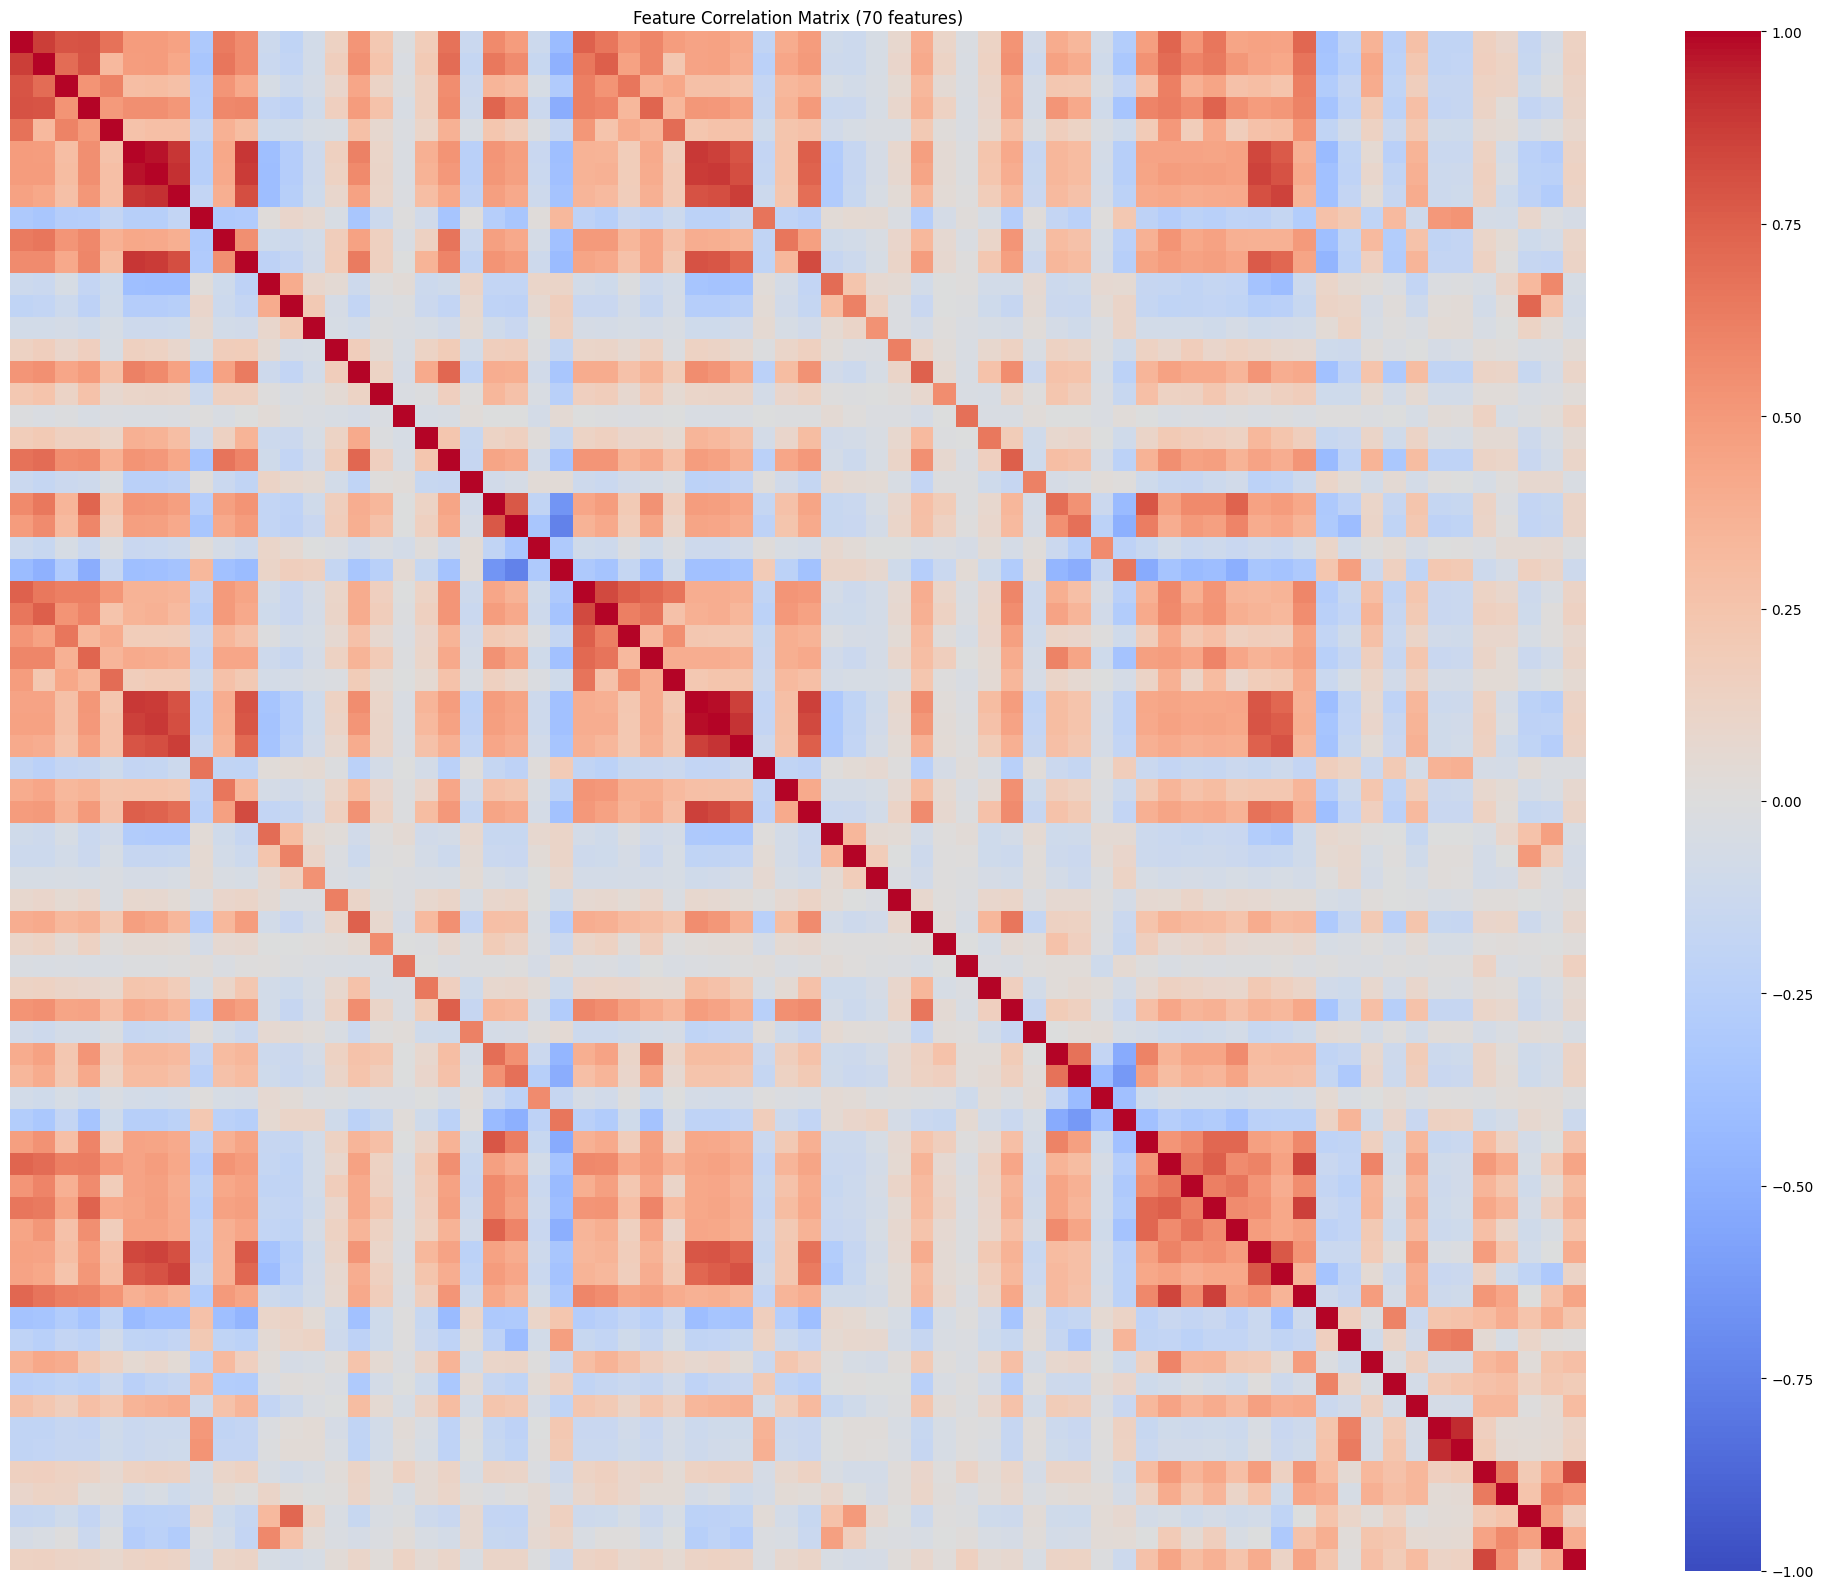

Feature pairs with |correlation| > 0.95: 2
  0.979  diff_TEAM_PASSES_5_last_match_average  ↔  diff_TEAM_SUCCESSFUL_PASSES_5_last_match_average
  0.972  diff_TEAM_PASSES_season_average  ↔  diff_TEAM_SUCCESSFUL_PASSES_season_average


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = X.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False)
plt.title(f"Feature Correlation Matrix ({X.shape[1]} features)")
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = abs(corr_matrix.iloc[i, j])
        if r > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
print(f"Feature pairs with |correlation| > 0.95: {len(high_corr_pairs)}")
for a, b, r in high_corr_pairs[:20]:
    print(f"  {r:.3f}  {a}  ↔  {b}")

Top 20 features most correlated with target:
diff_TEAM_SHOTS_INSIDEBOX_season_average                 0.286713
diff_TEAM_GAME_WON_season_average                        0.262751
diff_TEAM_SHOTS_ON_TARGET_season_average                 0.259890
diff_TEAM_SHOTS_TOTAL_season_average                     0.258049
diff_TEAM_GOALS_season_average                           0.256591
diff_TEAM_BALL_POSSESSION_season_average                 0.254151
diff_player_PLAYER_KEY_PASSES_season_average             0.253274
diff_TEAM_GAME_LOST_season_average                       0.249925
diff_player_PLAYER_BIG_CHANCES_CREATED_season_average    0.248069
diff_TEAM_PASSES_season_average                          0.245599
diff_TEAM_SUCCESSFUL_PASSES_season_average               0.245112
diff_player_PLAYER_SHOTS_ON_TARGET_season_average        0.241195
diff_player_PLAYER_ACCURATE_PASSES_season_average        0.238905
diff_TEAM_DANGEROUS_ATTACKS_season_average               0.237617
diff_TEAM_SHOTS_INSIDEBOX_5_las

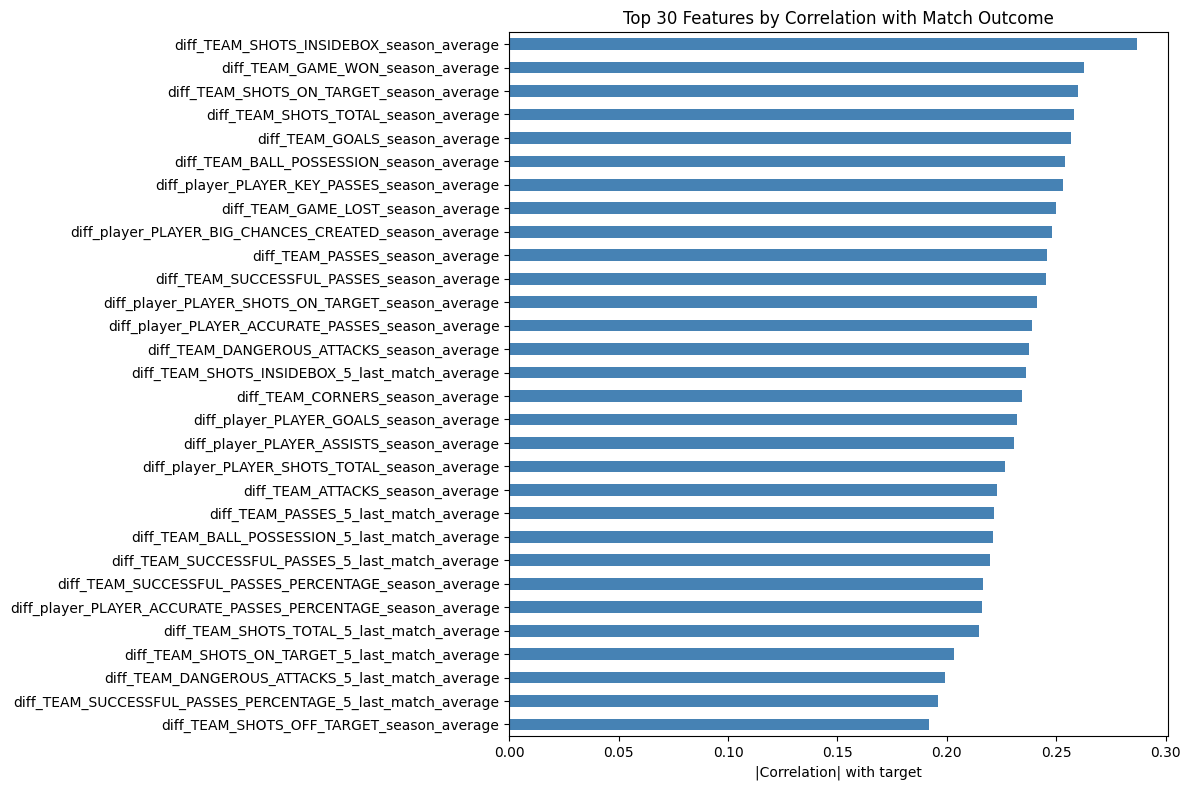

In [42]:
# Top features correlated with the target (y_label: 0=HOME, 1=DRAW, 2=AWAY)
target_corr = X.corrwith(pd.Series(y_label, index=X.index)).dropna().abs().sort_values(ascending=False)

print("Top 20 features most correlated with target:")
print(target_corr.head(20).to_string())
print(f"\nBottom 10 (least correlated — candidates for removal):")
print(target_corr.tail(10).to_string())

plt.figure(figsize=(12, 8))
target_corr.head(30).plot(kind="barh", color="steelblue")
plt.xlabel("|Correlation| with target")
plt.title("Top 30 Features by Correlation with Match Outcome")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [43]:
# Drop one feature from each highly correlated pair (|r| > 0.95)
# Keep the one with higher target correlation
to_drop = set()
for a, b, r in high_corr_pairs:
    if a in to_drop or b in to_drop:
        continue
    corr_a = target_corr.get(a, 0)
    corr_b = target_corr.get(b, 0)
    drop = b if corr_a >= corr_b else a
    to_drop.add(drop)

print(f"Dropping {len(to_drop)} redundant features (|r| > 0.95 with a better-correlated partner):")
for d in sorted(to_drop):
    print(f"  - {d}")

feature_cols = [c for c in feature_cols if c not in to_drop]
X = X.drop(columns=list(to_drop), errors="ignore")
print(f"\nRemaining features: {X.shape[1]}")

Dropping 2 redundant features (|r| > 0.95 with a better-correlated partner):
  - diff_TEAM_SUCCESSFUL_PASSES_5_last_match_average
  - diff_TEAM_SUCCESSFUL_PASSES_season_average

Remaining features: 68


## Model Training (Basic → Advanced)

Train 4 models in order of complexity to see how much added sophistication helps:
1. **Logistic Regression** — linear baseline (needs imputation + scaling)
2. **Gradient Boosting** — sklearn tree ensemble (needs imputation)
3. **LightGBM** — advanced tree ensemble (handles NaN natively)
4. **Neural Network (MLP)** — non-linear model (needs imputation + scaling)

In [45]:
# 1) Logistic Regression — linear baseline (needs imputation + scaling)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, multi_class="multinomial", random_state=42))
])

scores_lr = cross_val_score(lr_pipeline, X, y_label, cv=5, scoring="accuracy")
print("Logistic Regression CV accuracy:", scores_lr.mean().round(4), "±", scores_lr.std().round(4))

/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bu

Logistic Regression CV accuracy: 0.4958 ± 0.0065


In [46]:
# Fill NaN if any (e.g. with 0 or median)
X = X.fillna(X.median())

# Simple baseline: Gradient Boosting (team-only, as in README benchmark)
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
scores = cross_val_score(model, X, y_label, cv=5, scoring="accuracy")
print("CV accuracy (mean ± std):", scores.mean().round(4), "±", scores.std().round(4))

CV accuracy (mean ± std): 0.4844 ± 0.006


In [47]:
# LightGBM with native NaN handling (no imputation needed)
import lightgbm as lgb

X_raw = X_team[feature_cols].copy()
model_lgb = lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=-1)
scores_lgb = cross_val_score(model_lgb, X_raw, y_label, cv=5, scoring="accuracy")
print("LightGBM CV accuracy (mean ± std):", scores_lgb.mean().round(4), "±", scores_lgb.std().round(4))

LightGBM CV accuracy (mean ± std): 0.4857 ± 0.0063


In [48]:
# 4) Neural Network (MLP) — non-linear model (needs imputation + scaling)
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42, early_stopping=True))
])

scores_mlp = cross_val_score(mlp_pipeline, X, y_label, cv=5, scoring="accuracy")
print("Neural Network (MLP) CV accuracy:", scores_mlp.mean().round(4), "±", scores_mlp.std().round(4))

Neural Network (MLP) CV accuracy: 0.4881 ± 0.0046


## Model Comparison

Compare all 4 models side-by-side using multiple metrics (accuracy, F1, log loss) and per-class confusion matrices to see which model handles HOME/DRAW/AWAY best.

In [49]:
# Model comparison with multiple metrics
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "log_loss": "neg_log_loss",
}

X_imputed = X.copy().fillna(X.median())

models = {
    "Logistic Regression": lr_pipeline,
    "Gradient Boosting": model,
    "LightGBM": model_lgb,
    "Neural Network (MLP)": mlp_pipeline,
}

all_results = []
for name, mdl in models.items():
    data = X if name == "LightGBM" else (X_imputed if name == "Gradient Boosting" else X)
    cv = cross_validate(mdl, data, y_label, cv=5, scoring=scoring, return_train_score=False)
    all_results.append({
        "Model": name,
        "Accuracy": f"{cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}",
        "F1 (macro)": f"{cv['test_f1_macro'].mean():.4f} ± {cv['test_f1_macro'].std():.4f}",
        "F1 (weighted)": f"{cv['test_f1_weighted'].mean():.4f} ± {cv['test_f1_weighted'].std():.4f}",
        "Log Loss": f"{-cv['test_log_loss'].mean():.4f} ± {cv['test_log_loss'].std():.4f}",
    })

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bu

               Model        Accuracy      F1 (macro)   F1 (weighted)        Log Loss
 Logistic Regression 0.4958 ± 0.0065 0.3721 ± 0.0056 0.4215 ± 0.0054 1.0195 ± 0.0064
   Gradient Boosting 0.4844 ± 0.0060 0.4009 ± 0.0069 0.4404 ± 0.0066 1.0355 ± 0.0067
            LightGBM 0.4865 ± 0.0091 0.3974 ± 0.0113 0.4384 ± 0.0102 1.0344 ± 0.0065
Neural Network (MLP) 0.4881 ± 0.0046 0.3911 ± 0.0076 0.4338 ± 0.0073 1.0279 ± 0.0039


/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bu

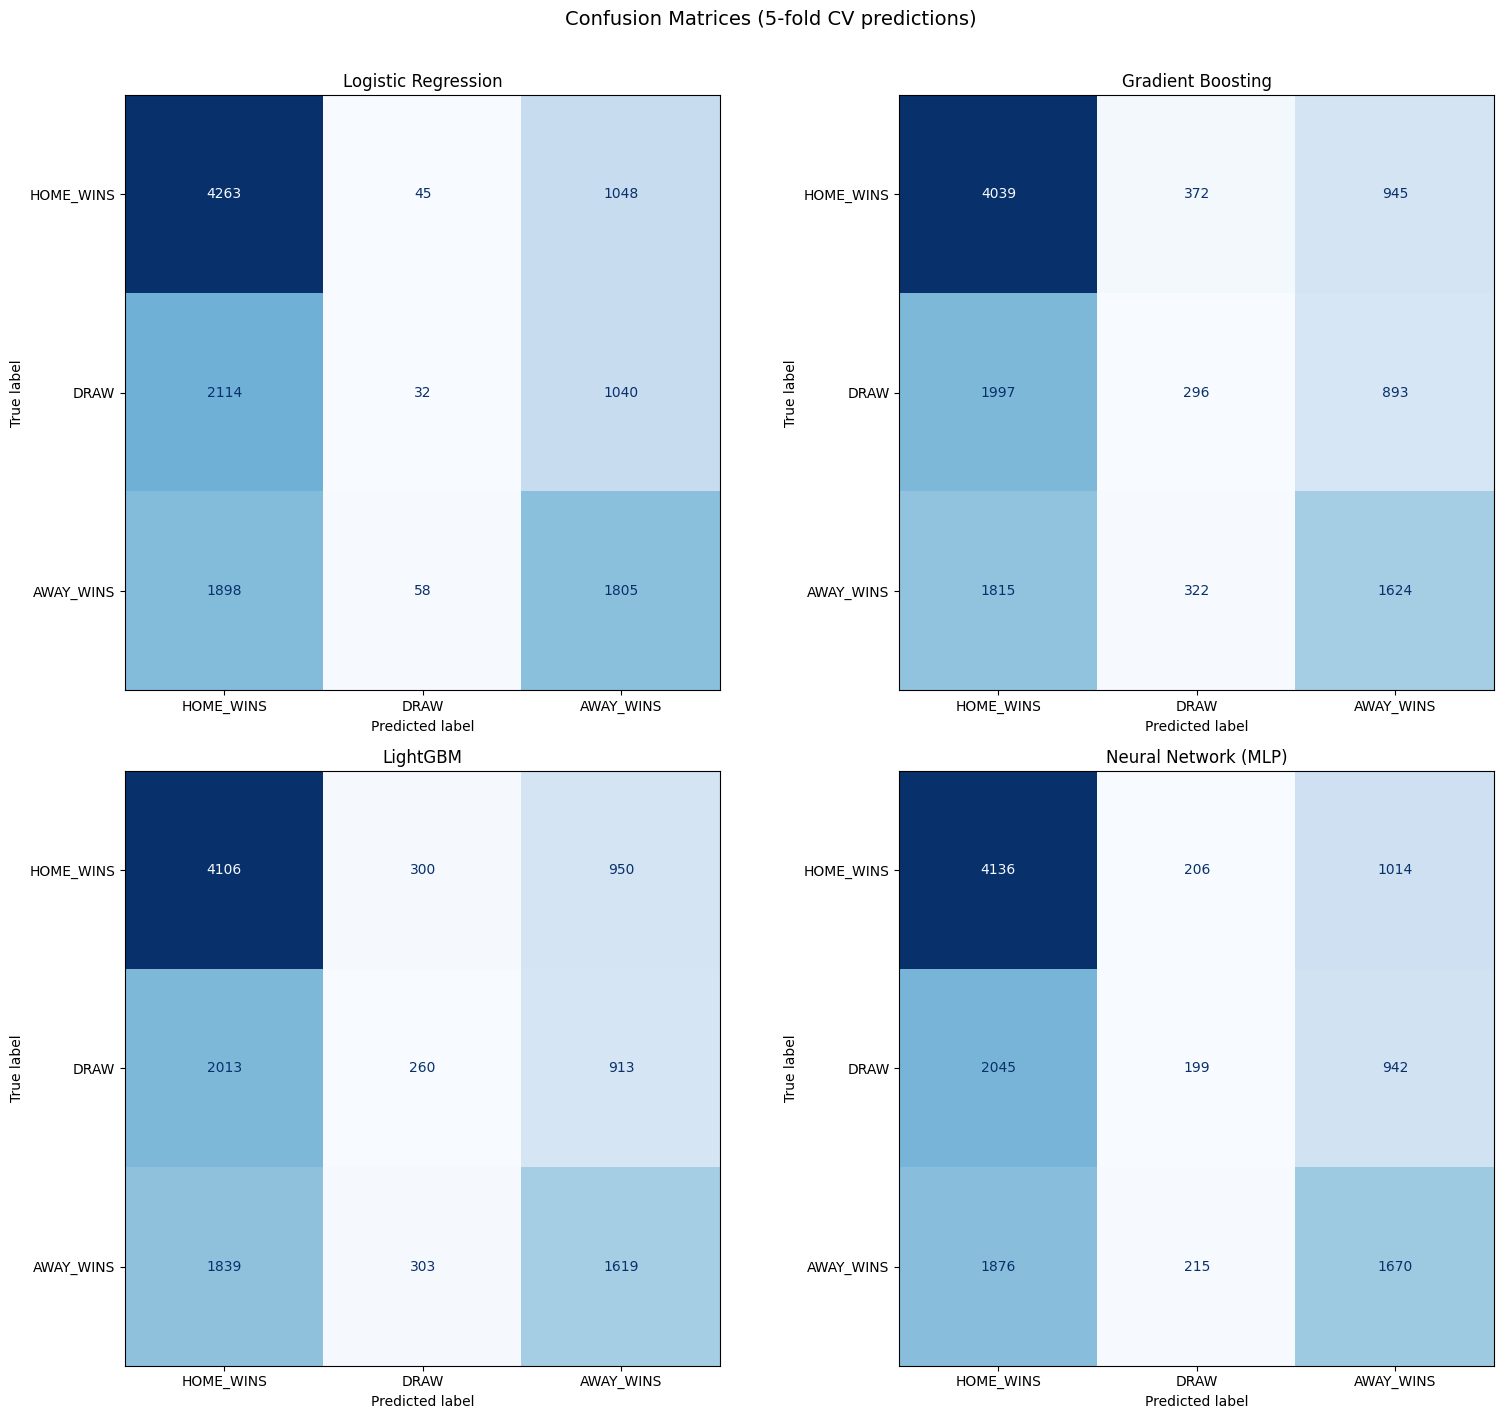


--- Classification Reports ---


/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/thanhtien.bu


Logistic Regression:
              precision    recall  f1-score   support

   HOME_WINS       0.52      0.80      0.63      5356
        DRAW       0.24      0.01      0.02      3186
   AWAY_WINS       0.46      0.48      0.47      3761

    accuracy                           0.50     12303
   macro avg       0.41      0.43      0.37     12303
weighted avg       0.43      0.50      0.42     12303


Gradient Boosting:
              precision    recall  f1-score   support

   HOME_WINS       0.51      0.75      0.61      5356
        DRAW       0.30      0.09      0.14      3186
   AWAY_WINS       0.47      0.43      0.45      3761

    accuracy                           0.48     12303
   macro avg       0.43      0.43      0.40     12303
weighted avg       0.44      0.48      0.44     12303


LightGBM:
              precision    recall  f1-score   support

   HOME_WINS       0.52      0.77      0.62      5356
        DRAW       0.30      0.08      0.13      3186
   AWAY_WINS       0.4

In [50]:
# Detailed per-class breakdown: confusion matrix + classification report
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

label_names = ["HOME_WINS", "DRAW", "AWAY_WINS"]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, (name, mdl) in zip(axes.flat, models.items()):
    data = X if name == "LightGBM" else (X_imputed if name == "Gradient Boosting" else X)
    y_pred = cross_val_predict(mdl, data, y_label, cv=5)
    cm = confusion_matrix(y_label, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrices (5-fold CV predictions)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n--- Classification Reports ---")
for name, mdl in models.items():
    data = X if name == "LightGBM" else (X_imputed if name == "Gradient Boosting" else X)
    y_pred = cross_val_predict(mdl, data, y_label, cv=5)
    print(f"\n{name}:")
    print(classification_report(y_label, y_pred, target_names=label_names))

## Benchmark vs default + Test prediction

We don't have test labels locally — the challenge only reports accuracy **after you submit**. So:

1. **Train (sanity check):** Compare your model vs "always HOME wins" on the **training set** to see if the model learns something.
2. **Test (real benchmark):** Build test features, predict, save **two** CSVs: your model (`submission.csv`) and the default (`submission_default.csv`). Submit both to the leaderboard; the leaderboard score on test data is the real "better than default or not".

In [51]:
# --- 1) Load test data and build same features ---
TEST_DIR = DATA_DIR / "Test_Data"
test_home_team = pd.read_csv(TEST_DIR / "test_home_team_statistics_df.csv")
test_away_team = pd.read_csv(TEST_DIR / "test_away_team_statistics_df.csv")
test_home_team = test_home_team.rename(columns={c: f"home_{c}" for c in test_home_team.columns if c != "ID"})
test_away_team = test_away_team.rename(columns={c: f"away_{c}" for c in test_away_team.columns if c != "ID"})
X_team_test = test_home_team.merge(test_away_team, on="ID", how="inner")

test_home_players = pd.read_csv(TEST_DIR / "test_home_player_statistics_df.csv")
test_away_players = pd.read_csv(TEST_DIR / "test_away_player_statistics_df.csv")
home_player_agg_test = player_team_agg(test_home_players, "home")
away_player_agg_test = player_team_agg(test_away_players, "away")
player_features_test = home_player_agg_test.merge(away_player_agg_test, on="ID", how="outer")
X_team_test = X_team_test.merge(player_features_test, on="ID", how="left")

# Build diff features for test (same as train)
for hc in feature_cols:
    if hc.startswith("diff_"):
        home_col = hc.replace("diff_", "home_", 1)
        away_col = hc.replace("diff_", "away_", 1)
        if home_col in X_team_test.columns and away_col in X_team_test.columns:
            X_team_test[hc] = X_team_test[home_col] - X_team_test[away_col]

test_ids = X_team_test["ID"]
train_median = X.median()

# --- 2) Train all 4 models on full train and predict test ---
X_filled = X.fillna(train_median)
X_test_filled = X_team_test.reindex(columns=feature_cols).fillna(train_median)
X_test_raw = X_team_test.reindex(columns=feature_cols)

submission_models = {
    "submission_lr.csv": ("Logistic Regression", lr_pipeline, X, X_team_test.reindex(columns=feature_cols)),
    "submission_gb.csv": ("Gradient Boosting", model, X_filled, X_test_filled),
    "submission_lgb.csv": ("LightGBM", model_lgb, X, X_test_raw),
    "submission_mlp.csv": ("Neural Network (MLP)", mlp_pipeline, X, X_team_test.reindex(columns=feature_cols)),
}

print("Training on full data and generating submissions...\n")
for filename, (name, mdl, X_train_data, X_test_data) in submission_models.items():
    mdl.fit(X_train_data, y_label)
    train_acc = (mdl.predict(X_train_data) == y_label).mean()
    pred = mdl.predict(X_test_data)
    sub = pd.DataFrame({"ID": test_ids})
    sub["HOME_WINS"] = (pred == 0).astype(int)
    sub["DRAW"] = (pred == 1).astype(int)
    sub["AWAY_WINS"] = (pred == 2).astype(int)
    sub.to_csv(DATA_DIR / filename, index=False)
    print(f"{name:25s} | Train acc: {train_acc:.4f} | Saved: {filename}")

# Default baseline
sub_default = pd.DataFrame({"ID": test_ids, "HOME_WINS": 1, "DRAW": 0, "AWAY_WINS": 0})
sub_default.to_csv(DATA_DIR / "submission_default.csv", index=False)
print(f"\n{'Default (always HOME)':25s} | Train acc: {(y_label == 0).mean():.4f} | Saved: submission_default.csv")
print(f"\nTotal: 5 submission files saved to data/")

Training on full data and generating submissions...

Logistic Regression       | Train acc: 0.5018 | Saved: submission_lr.csv


/Users/thanhtien.bui.int/Desktop/aml/aml_proj1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Gradient Boosting         | Train acc: 0.7243 | Saved: submission_gb.csv
LightGBM                  | Train acc: 0.6793 | Saved: submission_lgb.csv
Neural Network (MLP)      | Train acc: 0.5193 | Saved: submission_mlp.csv

Default (always HOME)     | Train acc: 0.4353 | Saved: submission_default.csv

Total: 5 submission files saved to data/
